# Hw2.3 - Аналіз книг Amazon Top-50

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 1. Прочитайте csv файл

In [2]:
df = pd.read_csv('bestsellers with categories.csv')
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

## 2. Виведіть перші п'ять рядків

In [3]:
df.head()

,name,author,user_rating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


## 3. Виведіть розміри датасету

In [4]:
df.shape

(550, 7)

**Відповідь: Про скільки книг зберігає дані датасет? - 550 записів (351 унікальна назва книги, деякі книги зустрічаються в різних роках)**

## Перевірка на дублікати

In [5]:
print(f'Загальна кількість рядків: {len(df)}')
print(f'Унікальних назв книг: {df["name"].nunique()}')
print(f'Кількість дублікатів: {df.duplicated(subset="name").sum()}')

Загальна кількість рядків: 550
Унікальних назв книг: 351
Кількість дублікатів: 199


## 4. Перевірка пропусків

In [6]:
df.isna().sum()

name           0
author         0
user_rating    0
reviews        0
price          0
year           0
genre          0
dtype: int64

**Відповідь: Чи є в якихось змінних пропуски? - Ні**

## 5. Унікальні значення в колонці genre

In [7]:
df['genre'].unique()

<StringArray>
['Non Fiction', 'Fiction']
Length: 2, dtype: str

**Відповідь: Які є унікальні жанри? - Fiction, Non Fiction**

## 6. Розподіл цін

In [8]:
print(f'Максимальна ціна: {df["price"].max()}')
print(f'Мінімальна ціна: {df["price"].min()}')
print(f'Середня ціна: {df["price"].mean():.2f}')
print(f'Медіанна ціна: {df["price"].median():.2f}')

Максимальна ціна: 105
Мінімальна ціна: 0
Середня ціна: 13.10
Медіанна ціна: 11.00


**Відповідь: Максимальна ціна? - 105**

**Відповідь: Мінімальна ціна? - 0**

**Відповідь: Середня ціна? - 13.10**

**Відповідь: Медіанна ціна? - 11.00**

## 7. Найвищий рейтинг

In [9]:
highest_rating = df['user_rating'].max()
count_highest = len(df[df['user_rating'] == highest_rating])
print(f'Найвищий рейтинг: {highest_rating}')
print(f'Кількість книг з таким рейтингом: {count_highest}')

Найвищий рейтинг: 4.9
Кількість книг з таким рейтингом: 52


**Відповідь: Який рейтинг у датасеті найвищий? - 4.9**

**Відповідь: Скільки книг мають такий рейтинг? - 52**

## 8. Книга з найбільше відгуків

In [10]:
most_reviewed = df.loc[df['reviews'].idxmax()]
print(f'Книга з найбільше відгуків: {most_reviewed["name"]} ({most_reviewed["reviews"]} відгуків)')

Книга з найбільше відгуків: Where the Crawdads Sing (87841 відгуків)


**Відповідь: Яка книга має найбільше відгуків? - Where the Crawdads Sing**

## 9. Найдорожча книга у 2015 році

In [11]:
books_2015 = df[df['year'] == 2015]
most_expensive_2015 = books_2015.loc[books_2015['price'].idxmax()]
print(f'Найдорожча книга у 2015: {most_expensive_2015["name"]} - ${most_expensive_2015["price"]}')

Найдорожча книга у 2015: Publication Manual of the American Psychological Association, 6th Edition - $46


**Відповідь: З тих книг, що потрапили до Топ-50 у 2015 році, яка книга найдорожча? - Publication Manual of the American Psychological Association, 6th Edition**

## 10. Кількість книг жанру Fiction у 2010 році

In [12]:
fiction_2010 = len(df[(df['genre'] == 'Fiction') & (df['year'] == 2010)])
print(f'Кількість книг жанру Fiction у 2010: {fiction_2010}')

Кількість книг жанру Fiction у 2010: 20


**Відповідь: Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році? - 20**

## 11. Книги з рейтингом 4.9 у 2010 та 2011 роках

In [13]:
rating_49_2010_2011 = len(df[(df['user_rating'] == 4.9) & (df['year'].isin([2010, 2011]))])
print(f'Книги з рейтингом 4.9 у 2010-2011: {rating_49_2010_2011}')

Книги з рейтингом 4.9 у 2010-2011: 1


**Відповідь: Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках? - 1**

## 12. Сортування книг 2015 року дешевше за 8 доларів

In [14]:
books_2015_cheap = df[(df['year'] == 2015) & (df['price'] < 8)].sort_values('price')
if len(books_2015_cheap) > 0:
    print('Остання книга у відсортованому списку:')
    print(books_2015_cheap.iloc[-1][['name', 'price']])

Остання книга у відсортованому списку:
name     Old School (Diary of a Wimpy Kid #10)
price                                        7
Name: 253, dtype: object


**Відповідь: Яка книга остання у відсортованому списку? - Old School (Diary of a Wimpy Kid #10)**

## 13. Максимальна та мінімальна ціна для кожного жанру

In [15]:
genre_prices = df.groupby('genre')['price'].agg(['min', 'max'])
genre_prices

,min,max
genre,,
Fiction,0,82
Non Fiction,0,105


**Відповідь: Максимальна ціна для жанру Fiction: 82**

**Відповідь: Мінімальна ціна для жанру Fiction: 0**

**Відповідь: Максимальна ціна для жанру Non Fiction: 105**

**Відповідь: Мінімальна ціна для жанру Non Fiction: 0**

## 14. Кількість книг для кожного автора

In [16]:
author_counts = df.groupby('author').size().reset_index(name='count').sort_values('count', ascending=False)
print(f'Розмір таблиці: {author_counts.shape}')
print(f'Автор з найбільше книг: {author_counts.iloc[0]["author"]} - {author_counts.iloc[0]["count"]} книг')
author_counts.head(10)

Розмір таблиці: (248, 2)
Автор з найбільше книг: Jeff Kinney - 12 книг


,author,count
120,Jeff Kinney,12
92,Gary Chapman,11
197,Rick Riordan,11
226,Suzanne Collins,11
11,American Psychological Association,10
73,Dr. Seuss,9
90,Gallup,9
199,Rob Elliott,8
58,Dav Pilkey,7
27,Bill O'Reilly,7


**Відповідь: Якого розмірності вийшла таблиця? - (248, 2)**

**Відповідь: Який автор має найбільше книг? - Jeff Kinney**

**Відповідь: Скільки книг цього автора? - 12**

## 15. Середній рейтинг для кожного автора

In [17]:
author_ratings = df.groupby('author')['user_rating'].mean().reset_index(name='avg_rating').sort_values('avg_rating')
print(f'Автор з мінімальним середнім рейтингом: {author_ratings.iloc[0]["author"]} - {author_ratings.iloc[0]["avg_rating"]:.2f}')
author_ratings.head()

Автор з мінімальним середнім рейтингом: Donna Tartt - 3.90


,author,avg_rating
71,Donna Tartt,3.9
90,Gallup,4.0
100,Gillian Flynn,4.0
171,Muriel Barbery,4.0
109,Ian K. Smith M.D.,4.1


**Відповідь: У якого автора середній рейтинг мінімальний? - Donna Tartt**

**Відповідь: Який у цього автора середній рейтинг? - 3.90**

## 16. З'єднання таблиць та сортування

In [18]:
merged = pd.concat([author_counts.set_index('author'), author_ratings.set_index('author')], axis=1)
merged = merged.sort_values(['count', 'avg_rating'])
print(f'Перший автор у списку: {merged.index[0]}')
merged.head(10)

Перший автор у списку: Muriel Barbery


,count,avg_rating
author,,
Muriel Barbery,1,4.0
Ian K. Smith M.D.,1,4.1
Chris Cleave,1,4.1
Pierre Dukan,1,4.1
Geneen Roth,1,4.2
Elizabeth Strout,1,4.2
Michael Wolff,1,4.2
Mark Hyman M.D.,1,4.2
Mark Twain,1,4.2


**Відповідь: Який автор перший у списку? - Muriel Barbery**

## Графік 1: Розподіл цін книг

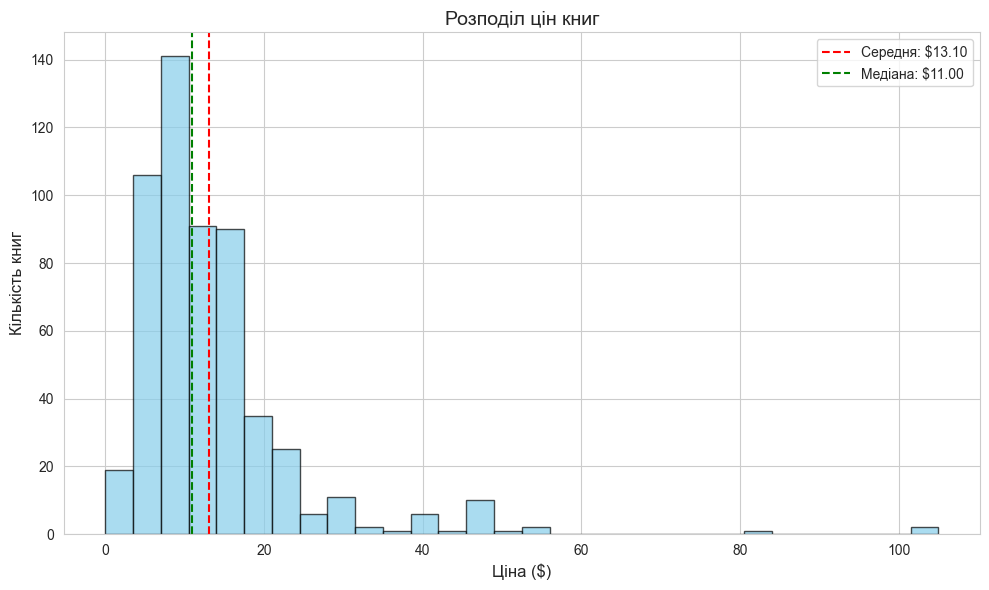

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Розподіл цін книг', fontsize=14)
plt.xlabel('Ціна ($)', fontsize=12)
plt.ylabel('Кількість книг', fontsize=12)
plt.axvline(df['price'].mean(), color='red', linestyle='--', label=f'Середня: ${df["price"].mean():.2f}')
plt.axvline(df['price'].median(), color='green', linestyle='--', label=f'Медіана: ${df["price"].median():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

## Графік 2: Кількість книг за роками

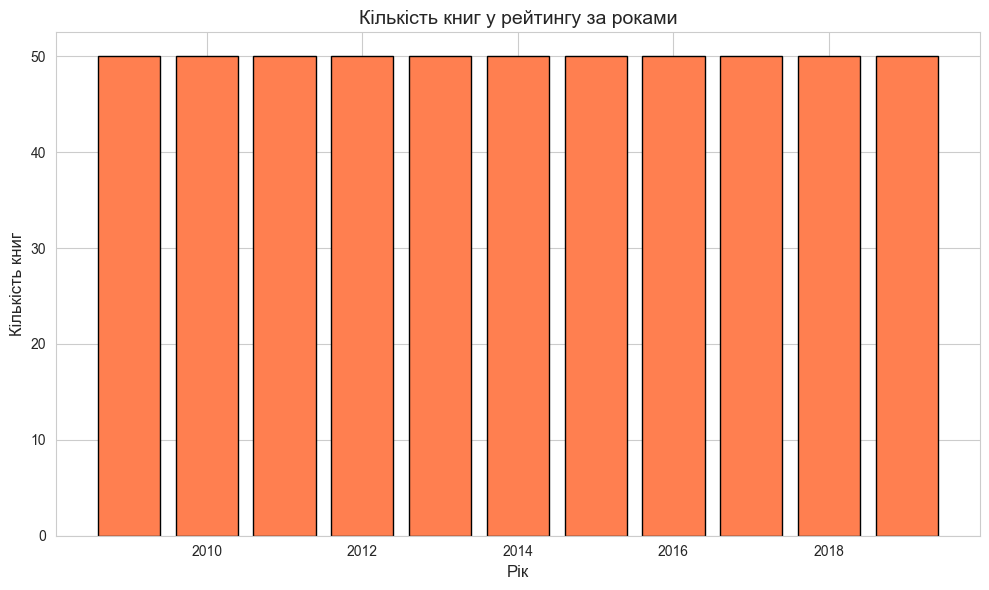

In [20]:
year_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(year_counts.index, year_counts.values, color='coral', edgecolor='black')
plt.title('Кількість книг у рейтингу за роками', fontsize=14)
plt.xlabel('Рік', fontsize=12)
plt.ylabel('Кількість книг', fontsize=12)
plt.tight_layout()
plt.show()

## Графік 3: Boxplot цін за жанром

C:\Users\e4493\AppData\Local\Temp\ipykernel_4724\2489610719.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y='price', palette='Set2')


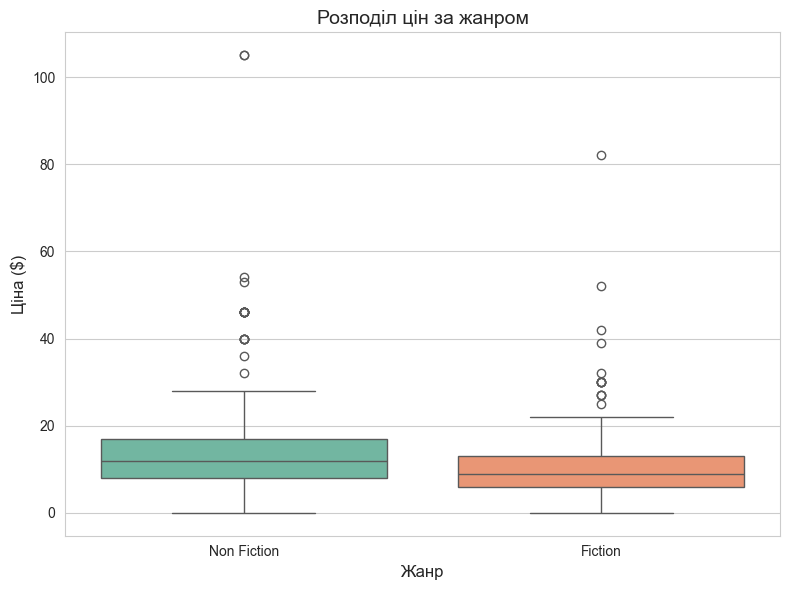

In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='genre', y='price', palette='Set2')
plt.title('Розподіл цін за жанром', fontsize=14)
plt.xlabel('Жанр', fontsize=12)
plt.ylabel('Ціна ($)', fontsize=12)
plt.tight_layout()
plt.show()

## Графік 4: Scatter plot рейтингу та кількості відгуків

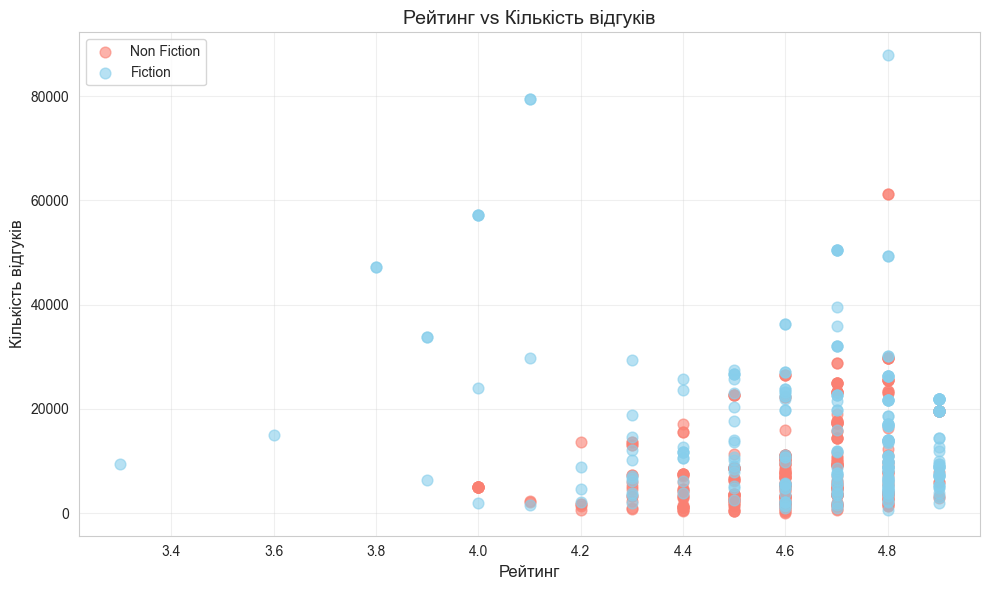

In [22]:
plt.figure(figsize=(10, 6))
colors = {'Fiction': 'skyblue', 'Non Fiction': 'salmon'}
for genre in df['genre'].unique():
    subset = df[df['genre'] == genre]
    plt.scatter(subset['user_rating'], subset['reviews'], 
               c=colors[genre], label=genre, alpha=0.6, s=60)

plt.title('Рейтинг vs Кількість відгуків', fontsize=14)
plt.xlabel('Рейтинг', fontsize=12)
plt.ylabel('Кількість відгуків', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Графік 5: Top-10 авторів за кількістю книг

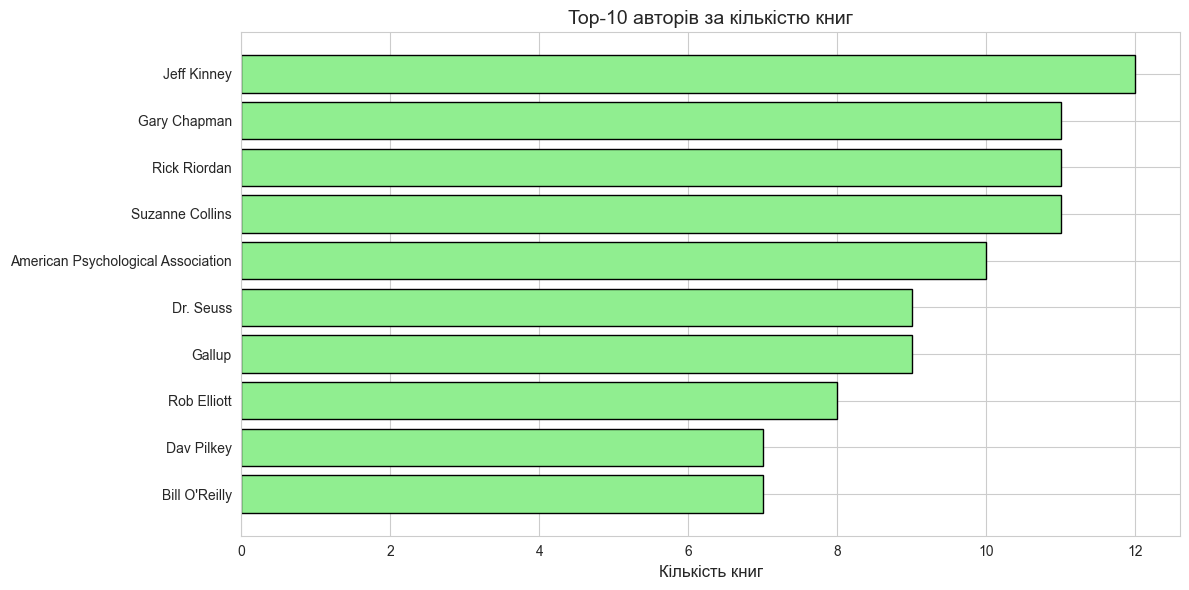

In [23]:
top_authors = author_counts.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_authors['author'][::-1], top_authors['count'][::-1], color='lightgreen', edgecolor='black')
plt.title('Top-10 авторів за кількістю книг', fontsize=14)
plt.xlabel('Кількість книг', fontsize=12)
plt.tight_layout()
plt.show()